In [ ]:
using SparseArrays
using LinearAlgebra
using Arpack
using Statistics
using Random
using DelimitedFiles
using NPZ
using ExpmV
using Dates

Random.seed!(Dates.now().instant.periods.value)

function random_product_state(L::Int)
    ψ = nothing
    for i in 1:L
        θ1, θ2 = rand() * π, rand() * π
        ϕ1, ϕ2 = rand() * 2π, rand() * 2π
        c1 = cos(θ1 / 2)
        c2 = exp(im * ϕ1) * sin(θ1 / 2) * sin(θ2 / 2)
        c3 = exp(im * ϕ2) * sin(θ1 / 2) * cos(θ2 / 2)
        site_state = [c1, c2, c3]
        ψ = i == 1 ? site_state : kron(ψ, site_state)
    end
    return ψ / norm(ψ)
end

function superposition_state(L::Int)
    # single-site state (|0> + |1> + |2>) / sqrt(3)
    φ = ones(ComplexF64, 3) / sqrt(3)

    ψ = φ
    for _ in 2:L
        ψ = kron(ψ, φ)
    end

    return ψ
end

# ---------------------------------------------------------
# Haar-random unitary (3×3), converted to sparse
# ---------------------------------------------------------
function haar_unitary_sparse(n::Int)
    A = randn(ComplexF64, n, n)
    Q, R = qr(A)
    phases = Diagonal(R) ./ abs.(Diagonal(R))
    return sparse(Q * Diagonal(phases))
end

# ---------------------------------------------------------
# Build 9×9 Z3-conserving Haar unitary as sparse blockdiag
#
# Basis ordering (Z3 sectors):
#   charge 0: 00, 12, 21
#   charge 1: 01, 10, 22
#   charge 2: 02, 20, 11
#
# So U_z3 is blockdiag(U0, U1, U2)
# ---------------------------------------------------------
function z3_haar()
    U0 = haar_unitary_sparse(3)
    U1 = haar_unitary_sparse(3)
    U2 = haar_unitary_sparse(3)
    return blockdiag(U0, U1, U2)  # built-in sparse blockdiag
end

# ---------------------------------------------------------
# Sparse permutation matrix: Z3 basis → standard lexicographic basis
#
# Z3 basis order:
#   ["00","12","21",  "01","10","22",  "02","20","11"]
#
# Standard basis order:
#   ["00","01","02",  "10","11","12",  "20","21","22"]
# ---------------------------------------------------------
function permutation_matrix_sparse()
    z3  = ["00","12","21","01","10","22","02","20","11"]
    std = ["00","01","02","10","11","12","20","21","22"]

    rows = Int[]
    cols = Int[]
    vals = ComplexF64[]

    for (i, state) in enumerate(z3)
        j = findfirst(==(state), std)
        push!(rows, j)
        push!(cols, i)
        push!(vals, 1.0 + 0im)
    end

    return sparse(rows, cols, vals, 9, 9)
end

# ---------------------------------------------------------
# Apply sparse basis change: U_std = P * U_z3 * P'
# ---------------------------------------------------------
function transform(U_z3)
    P = permutation_matrix_sparse()
    return P * U_z3 * P'
end

function odd_layer(L::Int)
    U = transform(z3_haar())
    for _ in 3:2:L-1
        U = kron(U, transform(z3_haar()))
    end
    return U
end

function even_layer(L::Int)
    id = sparse(ComplexF64[1 0 0; 0 1 0; 0 0 1])
    U = id
    for _ in 2:2:L-1
        U = kron(U, transform(z3_haar()))
    end
    return kron(U, id)
end

function time_evolution(ψ::Vector{ComplexF64}, L)

    U_odd  = odd_layer(L)
    U_even = even_layer(L)

    ψ_odd = U_odd * ψ
    ψ_even = U_even * ψ_odd

    return normalize!(ψ_even)
end

function entropy_vn(ψ::Vector{<:Complex}, L::Int, subsystem::AbstractArray{Int})
    cut = length(subsystem)
    dimA = 3^cut
    dimB = 3^(L - cut)
    
    ψ_matrix = reshape(ψ, (dimA, dimB))
    svals = svdvals(ψ_matrix)

    
    S = 0.0
    
    for s in svals
        if s > 1e-15
            p = abs2(s)
            S -= p * log(p)
        end
    end
    return S
end

function get_z3_operators()
    id = sparse(ComplexF64[1 0 0; 0 1 0; 0 0 1])
    τ = sparse(ComplexF64[1 0 0; 0 exp(2im * pi / 3) 0; 0 0 exp(4im * pi / 3)]) ## τ in Romain's paper

    return id, τ
end

function build_term(operators::Vector{<:SparseMatrixCSC}) #
    term = operators[1]
    for j in 2:length(operators)
        term = kron(term, operators[j])
    end
    return term
end

function create_local_q_operator(L::Int, site::Int)
    id, τ = get_z3_operators()
    ops = fill(id, L)
    ops[site] = (im / sqrt(3)) * (τ' - τ)
    return build_term(ops)
end

function charge_expectation(ψ::Vector{ComplexF64}, L::Int)
    ω = cis(2pi / 3)   
    expU = zero(ComplexF64)

    for (idx, amp) in enumerate(ψ)
        n = idx - 1
        q = 0
        @inbounds for _ in 1:L
            q += n % 3
            n ÷= 3
        end
        expU += abs2(amp) * ω^q
    end

    return expU
end

function shannon_entropy(ψ::Vector{ComplexF64}, L::Int)
    # Probabilities for the three Z₃ charge sectors
    p0 = 0.0
    p1 = 0.0
    p2 = 0.0

    for (idx, amp) in enumerate(ψ)
        # Decode basis index -> total charge mod 3
        n = idx - 1
        q = 0
        for _ in 1:L
            q += n % 3
            n ÷= 3
        end
        q %= 3

        # Born probability
        w = abs2(amp)

        if q == 0
            p0 += w
        elseif q == 1
            p1 += w
        else
            p2 += w
        end
    end

    # Shannon entropy
    S = 0.0
    if p0 > 1e-15; S -= p0 * log(p0); end
    if p1 > 1e-15; S -= p1 * log(p1); end
    if p2 > 1e-15; S -= p2 * log(p2); end

    return S
end


function Entropy_t(L::Int, T::Float64, dt::Float64, p::Float64, shot::Int)
    
    # Initialize state
    #s_t = random_product_state(L)
    s_t = superposition_state(L)
    
    # Time evolution

    ω = exp(2im * pi / 3)
    
    # Build a list of single-site Q operators for measurement
    Ql = [create_local_q_operator(L, i) for i in 1:L]
    
    # Initialize lists to store results
    #S_list = Float64[]
    SE_list = Float64[]

    steps = Int(floor(T / dt))

    for _ in 1:steps
        
        # Record half-chain entropy
        #push!(S_list, entropy_vn(s_t, L, 1:L÷2))
        push!(SE_list, shannon_entropy(s_t, L))

        # Time evolution
        s_t = time_evolution(s_t, L)

        # Measurements
        if p != 0
            for l in 2:L-1 ## avoid edges
                if rand() < p ## edit this
                    p_m_zero  = real(s_t' * s_t) - real(s_t' * Ql[l] * Ql[l] * s_t)
                    p_m_one = 0.5 * real(s_t' * Ql[l] * s_t) + 0.5 * real(s_t' * Ql[l] * Ql[l] * s_t)
                    x1 = rand()
                    if x1 < p_m_zero
                        s_t = (s_t - (Ql[l] * Ql[l] * s_t)) / sqrt(p_m_zero)
                    elseif p_m_zero ≤ x1 < (p_m_one + p_m_zero)
                        s_t = 0.5 * (Ql[l] * s_t + Ql[l] * Ql[l] * s_t) / sqrt(p_m_one)
                    else
                        s_t = 0.5 * ((Ql[l] * Ql[l] * s_t) - s_t) / sqrt(1 - p_m_zero - p_m_one)
                    end
                end
            end
        end
    end

    """
    # Data storage for Jed's Mac
    base_folder = "/Users/uditvarma/Project_Data/z3-haar" 

    today_date = Dates.format(Dates.today(), "yyyy-mm-dd")
    parent_dir = dirname(base_folder)
    folder_name = basename(base_folder) * "_" * today_date
    folder = joinpath(parent_dir, folder_name)
    mkpath(folder)    
    filename_entropy = joinpath(folder, "L$(L),T$(T),dt$(dt),p$(p),dirQ,s$(shot)_hc.npy")
    npzwrite(filename_entropy, S_list)
    """

    """
    # Data storage for Udit's Mac
    base_folder = "/Users/dirac/Projects-Data/z3-haar-data" 

    today_date = Dates.format(Dates.today(), "yyyy-mm-dd")
    parent_dir = dirname(base_folder)
    folder_name = basename(base_folder) * "_" * today_date
    folder = joinpath(parent_dir, folder_name)
    mkpath(folder)    
    filename_entropy = joinpath(folder, "L$(L),T$(T),dt$(dt),p$(p),dirQ,s$(shot)_hc.npy")
    npzwrite(filename_entropy, S_list)
    """
    
    
    # Data storage for cluster
    filename_entropy = "L$(L),T$(T),dt$(dt),p$(p),dirQ,s$(shot)_se.npy"
    npzwrite(filename_entropy, SE_list)
    
    
    #println("Shannon entropy: ", shannon_entropy(s_t, L))

    return SE_list
end

Entropy_t (generic function with 1 method)

In [13]:
for p in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] 
    Entropy_t(8, 80.0, 1.0, p, 9)
end

Shannon entropy: 1.0986122886681098
Shannon entropy: 1.0967126046452922
Shannon entropy: 0.8419272409845808
Shannon entropy: 0.20357127619794932
Shannon entropy: 0.5765917756361165
Shannon entropy: 0.12610556220865113
Shannon entropy: 0.7915288269972179
Shannon entropy: 0.1922007116804223
Shannon entropy: 0.0002405629227781242
Shannon entropy: 5.606076070492118e-6
Shannon entropy: 0.07447655023439195


In [ ]:
function total_q_product(L::Int)
    id, τ = get_z3_operators()
    op = sparsezero(ComplexF64, 3^L, 3^L)
    for i in 1:L
        op = kron

In [4]:
id, τ = get_z3_operators()
(im / sqrt(3)) * (τ' - τ)

3×3 SparseMatrixCSC{ComplexF64, Int64} with 2 stored entries:
     ⋅          ⋅           ⋅    
     ⋅      1.0+0.0im       ⋅    
     ⋅          ⋅      -1.0+0.0im

In [5]:
function global_charge_exp_cheeky(ψ::Vector{ComplexF64}, L::Int)
    ω = exp(2im * pi / 3)
    expU = 0.0 + 0.0im

    for (idx, amp) in enumerate(ψ)
        # Convert index to base-3 digits (site occupations)
        n = idx - 1
        charge = 0
        for _ in 1:L
            charge += n % 3
            n ÷= 3
        end
        expU += abs2(amp) * ω^charge
    end

    varU = 1.0 - abs2(expU)
    return expU, real(varU)
end

global_charge_exp_cheeky (generic function with 1 method)

In [14]:
psi = [1.0+0.0im, 0.0+0.0im, 0.0+0.0im]

3-element Vector{ComplexF64}:
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [15]:
global_charge_exp_cheeky(psi, 1)

(1.0 + 0.0im, 0.0)

In [3]:
Entropy_t(8, 80.0, 1.0, 0.0, 1)

80-element Vector{ComplexF64}:
 -0.013699567088907901 - 0.054060593655172184im
 -0.013699567088907986 - 0.05406059365517216im
 -0.013699567088908154 - 0.054060593655172295im
 -0.013699567088908035 - 0.054060593655172046im
 -0.013699567088908049 - 0.05406059365517192im
 -0.013699567088908142 - 0.05406059365517209im
 -0.013699567088908043 - 0.0540605936551719im
  -0.01369956708890807 - 0.05406059365517219im
 -0.013699567088908104 - 0.054060593655172025im
 -0.013699567088908082 - 0.05406059365517239im
                       ⋮
  -0.01369956708890814 - 0.05406059365517241im
 -0.013699567088908066 - 0.05406059365517221im
 -0.013699567088908142 - 0.0540605936551722im
  -0.01369956708890817 - 0.05406059365517208im
 -0.013699567088908167 - 0.05406059365517249im
 -0.013699567088908095 - 0.054060593655172094im
 -0.013699567088908128 - 0.0540605936551724im
  -0.01369956708890806 - 0.054060593655172004im
 -0.013699567088908203 - 0.054060593655172504im

Jan 29 - Optimizing the code

In [3]:
using LinearAlgebra

In [4]:
function random_product_state(L::Int)
    dim = 3^L
    ψ = Vector{ComplexF64}(undef, dim)

    # generate local states
    locals = Vector{NTuple{3,ComplexF64}}(undef, L)
    for i in 1:L
        θ1, θ2 = rand() * π, rand() * π
        ϕ1, ϕ2 = rand() * 2π, rand() * 2π

        locals[i] = (
            cos(θ1 / 2),
            exp(im * ϕ1) * sin(θ1 / 2) * sin(θ2 / 2),
            exp(im * ϕ2) * sin(θ1 / 2) * cos(θ2 / 2)
        )
    end

    # fill ψ using base-3 indexing
    for idx in 0:dim-1
        x = idx
        amp = one(ComplexF64)
        for i in 1:L
            s = (x % 3) + 1
            amp *= locals[i][s]
            x ÷= 3
        end
        ψ[idx + 1] = amp
    end

    normalize!(ψ)
    return ψ
end

random_product_state (generic function with 1 method)

In [7]:
random_product_state(2)

9-element Vector{ComplexF64}:
    0.6468750349439875 + 0.0im
 -0.018738441179576973 - 0.183338637423011im
   0.02860801013517444 + 0.023981687232352052im
   0.16780504129827228 + 5.701239018864596e-5im
 -0.004844756951150714 - 0.04756129744645566im
  0.007419054391703378 + 0.006223580769061572im
   -0.6764269921614444 - 0.13389088193117427im
 -0.018353134392888323 + 0.19559281567502387im
 -0.024951188594131705 - 0.0309985873400837im

In [16]:
function superposition_state(L::Int)
    dim = 3^L
    fill(ComplexF64(1 / sqrt(dim)), dim)
end

superposition_state (generic function with 1 method)

In [20]:
psi = superposition_state(12)

531441-element Vector{ComplexF64}:
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
                       ⋮
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im

In [10]:
function superposition_state(L::Int)
    # single-site state (|0> + |1> + |2>) / sqrt(3)
    φ = ones(ComplexF64, 3) / sqrt(3)

    ψ = φ
    for _ in 2:L
        ψ = kron(ψ, φ)
    end

    return ψ
end

superposition_state (generic function with 1 method)

In [11]:
superposition_state(3)

27-element Vector{ComplexF64}:
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
                     ⋮
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im

In [13]:
function permutation_matrix()
    z3  = ["00","12","21","01","10","22","02","20","11"]
    std = ["00","01","02","10","11","12","20","21","22"]

    P = zeros(ComplexF64, 9, 9)
    for (i, s) in enumerate(z3)
        j = findfirst(==(s), std)
        P[j, i] = 1
    end
    return P
end

permutation_matrix (generic function with 1 method)

In [14]:
permutation_matrix()

9×9 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     1.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  1.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im

In [15]:
using LinearAlgebra

function calculate_entropy(psi::AbstractVector, L::Integer, subsystem_sites::AbstractVector{<:Integer}; 
    d::Integer=3)
    # Check if vector size matches the physical dimensions
    if length(psi) != d^L
        error("Dimension mismatch: Vector length $(length(psi)) does not match d^L ($d^$L = $(d^L))")
    end

    # 1. Reshape vector into a tensor with L indices of dimension d
    # usage of Tuple(fill(d, L)) ensures type stability for reshape
    psi_tensor = reshape(psi, ntuple(_ -> d, L))

    # 2. Identify environment sites
    # Using a Set for 'subsystem_sites' makes the lookup O(1) instead of O(N)
    sub_set = Set(subsystem_sites)
    environment_sites = [i for i in 1:L if i ∉ sub_set]
    
    # 3. Permute dimensions to group subsystem sites at the front
    permute_order = vcat(subsystem_sites, environment_sites)
    psi_permuted = permutedims(psi_tensor, permute_order)

    # 4. Reshape into a Matrix (dim_subsystem x dim_environment)
    dim_subsystem = d^length(subsystem_sites)
    dim_environment = d^length(environment_sites)
    psi_matrix = reshape(psi_permuted, dim_subsystem, dim_environment)

    # 5. Compute Singular Values (SVD)
    # svdvals is much faster than svd() because it doesn't compute U and V vectors
    s = svdvals(psi_matrix)

    # 6. Compute Entropy
    s_squared = s.^2
    
    # Normalize here instead of normalizing 'psi' at the start (saves 2 allocations)
    total_prob = sum(s_squared)
    s_squared ./= total_prob

    # Filter non-zero values to avoid log(0)
    # Using a slightly higher tolerance for stability
    filter!(x -> x > 1e-15, s_squared)
    
    entropy = -sum(s_squared .* log.(s_squared))

    return entropy
end

calculate_entropy (generic function with 1 method)

In [24]:
psi = ghz(12)

531441-element Vector{ComplexF64}:
 0.5773502691896258 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                    ⋮
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
 0.5773502691896258 + 0.0im

In [25]:
calculate_entropy(psi, 12, 1:6)

1.0986122886681096

In [26]:
log(3)

1.0986122886681098

In [22]:
function ghz(L::Int; d::Int=3)
    # Total Hilbert space dimension
    dim_total = d^L
    
    # Initialize the state vector with zeros
    ψ = zeros(ComplexF64, dim_total)
    
    # We want to populate the states |00...0>, |11...1>, ... |d-1...d-1>.
    # In a flattened vector, these indices are perfectly spaced apart.
    # The step size (stride) is (d^L - 1) / (d - 1).
    stride = (dim_total - 1) ÷ (d - 1)
    
    # Normalization factor
    norm_factor = 1.0 / sqrt(d)
    
    # Fill the specific indices
    for k in 0:(d-1)
        # 1-based indexing: start at 1, add k steps
        idx = 1 + k * stride
        ψ[idx] = norm_factor
    end

    return ψ
end

ghz (generic function with 1 method)

Starting Simulation...
Threads available: 1
Simulating L = 6...
........... Done.
Simulating L = 8...
........... Done.
Simulating L = 10...
........... Done.


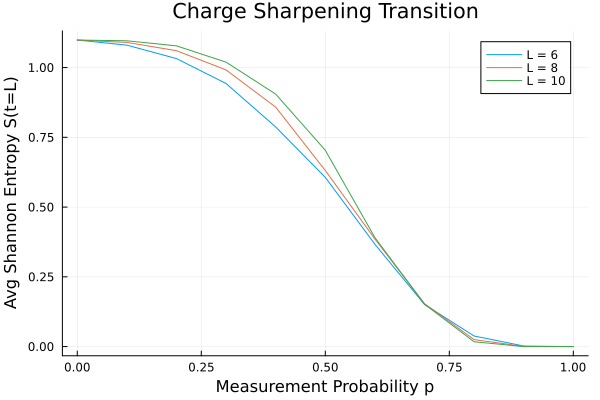

In [29]:
using LinearAlgebra
using Random
using StatsBase
using Plots

# ==========================================
# 1. CORE SIMULATION FUNCTIONS
# ==========================================

function construct_charge_conserving_gate()
    # Helper to generate 3x3 Haar random unitary
    function haar_3x3()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        d = diag(R)
        return Q * Diagonal(d ./ abs.(d))
    end

    U0, U1, U2 = haar_3x3(), haar_3x3(), haar_3x3()
    U = zeros(ComplexF64, 9, 9)
    
    # Indices mapping to Charge 0, 1, 2 sectors (see previous explanation)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    
    U[idx0, idx0] = U0
    U[idx1, idx1] = U1
    U[idx2, idx2] = U2
    return U
end

function apply_gate!(psi, U_gate, site, L)
    dim_L = 3^(site - 1)
    dim_R = 3^(L - site - 1)
    # Reshape: (Left, Site1, Site2, Right) -> Permute -> (Site1, Site2, Left, Right)
    psi_t = permutedims(reshape(psi, dim_L, 3, 3, dim_R), (2, 3, 1, 4))
    # Matrix multiply: (9 x Env)
    psi_new = U_gate * reshape(psi_t, 9, :)
    # Reshape back: (Site1, Site2, Left, Right) -> Permute -> (Left, Site1, Site2, Right)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dim_L, dim_R), (3, 1, 2, 4)), :)
end

function perform_measurements!(psi, L, p)
    for site in 1:L
        if rand() < p
            dim_L, dim_R = 3^(site-1), 3^(L-site)
            psi_t = reshape(psi, dim_L, 3, dim_R)
            
            # Calc probabilities for |0>, |1>, |2>
            probs = [sum(abs2, psi_t[:, s, :]) for s in 1:3]
            
            if sum(probs) > 1e-12
                outcome = sample(1:3, Weights(probs))
                norm_fac = 1.0 / sqrt(probs[outcome])
                
                # Project and Normalize
                for s in 1:3
                    if s != outcome
                        psi_t[:, s, :] .= 0
                    else
                        psi_t[:, s, :] .*= norm_fac
                    end
                end
            end
            psi[:] = psi_t
        end
    end
end

function get_final_entropy(psi, L)
    # Calculate probabilities of Total Charge Mod 3
    probs_charge = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            # Calculate sum of digits in base 3 efficiently
            val, total_charge = i, 0
            for _ in 1:L
                total_charge += val % 3
                val ÷= 3
            end
            probs_charge[(total_charge % 3) + 1] += amp
        end
    end
    # Shannon Entropy
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs_charge)
end

# ==========================================
# 2. EXPERIMENT RUNNER
# ==========================================

function run_single_realization(L, p)
    # Initial State: Equal superposition normalized
    psi = ones(ComplexF64, 3^L)
    psi ./= norm(psi)
    
    # Evolve for t = 1 to L
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Measurements
        perform_measurements!(psi, L, p)
    end
    
    return get_final_entropy(psi, L)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]          # System sizes
    p_values = 0.0:0.1:1.0        # Measurement probabilities
    n_realizations = 500            # Number of runs per point
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        println("Simulating L = $L...")
        avg_entropies = Float64[]
        
        for p in p_values
            # Run realizations in parallel for speed
            batch_entropies = zeros(n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            
            push!(avg_entropies, mean(batch_entropies))
            print(".") # Progress bar dot
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

# Create the plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Avg Shannon Entropy S(t=L)",
    title = "Charge Sharpening Transition",
    legend = :topright,
    lw = 2,
    marker = :circle
)

for (L, entropies) in sort(collect(data))
    plot!(plt, p_vals, entropies, label = "L = $L")
end

display(plt)
# savefig("charge_sharpening.png") # Uncomment to save

In [ ]:
using LinearAlgebra
using Random
using StatsBase
using Plots

# ==========================================
# 1. CORE SIMULATION FUNCTIONS
# ==========================================

function construct_charge_conserving_gate()
    # Helper to generate 3x3 Haar random unitary
    function haar_3x3()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        d = diag(R)
        return Q * Diagonal(d ./ abs.(d))
    end

    U0, U1, U2 = haar_3x3(), haar_3x3(), haar_3x3()
    U = zeros(ComplexF64, 9, 9)
    
    # Indices mapping to Charge 0, 1, 2 sectors (see previous explanation)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    
    U[idx0, idx0] = U0
    U[idx1, idx1] = U1
    U[idx2, idx2] = U2
    return U
end

function apply_gate!(psi, U_gate, site, L)
    dim_L = 3^(site - 1)
    dim_R = 3^(L - site - 1)
    # Reshape: (Left, Site1, Site2, Right) -> Permute -> (Site1, Site2, Left, Right)
    psi_t = permutedims(reshape(psi, dim_L, 3, 3, dim_R), (2, 3, 1, 4))
    # Matrix multiply: (9 x Env)
    psi_new = U_gate * reshape(psi_t, 9, :)
    # Reshape back: (Site1, Site2, Left, Right) -> Permute -> (Left, Site1, Site2, Right)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dim_L, dim_R), (3, 1, 2, 4)), :)
end

function perform_measurements!(psi, L, p)
    for site in 1:L
        if rand() < p
            dim_L, dim_R = 3^(site-1), 3^(L-site)
            psi_t = reshape(psi, dim_L, 3, dim_R)
            
            # Calc probabilities for |0>, |1>, |2>
            probs = [sum(abs2, psi_t[:, s, :]) for s in 1:3]
            
            if sum(probs) > 1e-12
                outcome = sample(1:3, Weights(probs))
                norm_fac = 1.0 / sqrt(probs[outcome])
                
                # Project and Normalize
                for s in 1:3
                    if s != outcome
                        psi_t[:, s, :] .= 0
                    else
                        psi_t[:, s, :] .*= norm_fac
                    end
                end
            end
            psi[:] = psi_t
        end
    end
end

function get_final_entropy(psi, L)
    # Calculate probabilities of Total Charge Mod 3
    probs_charge = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            # Calculate sum of digits in base 3 efficiently
            val, total_charge = i, 0
            for _ in 1:L
                total_charge += val % 3
                val ÷= 3
            end
            probs_charge[(total_charge % 3) + 1] += amp
        end
    end
    # Shannon Entropy
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs_charge)
end

# ==========================================
# 2. EXPERIMENT RUNNER
# ==========================================

function run_single_realization(L, p)
    # Initial State: Equal superposition normalized
    psi = ones(ComplexF64, 3^L)
    psi ./= norm(psi)
    
    # Evolve for t = 1 to L
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Measurements
        perform_measurements!(psi, L, p)
    end
    
    return get_final_entropy(psi, L)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [8, 12, 16]          # System sizes
    p_values = 0.0:0.05:1.0        # Measurement probabilities
    n_realizations = 500            # Number of runs per point
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        println("Simulating L = $L...")
        avg_entropies = Float64[]
        
        for p in p_values
            # Run realizations in parallel for speed
            batch_entropies = zeros(n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            
            push!(avg_entropies, mean(batch_entropies))
            print(".") # Progress bar dot
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

# Initialize the plot with general styling
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Avg Shannon Entropy S(t=L)",
    title = "Charge Sharpening Transition",
    legend = :topright,
    lw = 2,               # Line width
    guidefontsize = 12,   # Axis label size
    #tickfontsize = 10,    # Tick number size
    #framestyle = :box,    # Box around the plot
    #grid = true
)

# Plot each system size L
for (L, entropies) in sort(collect(data))
    plot!(plt, p_vals, entropies, 
        label = "L = $L",
        marker = :circle,     # Explicitly set marker shape
        markersize = 5,       # Make the circles large enough to be clearly visible
        markercolor = :auto   # Automatically match the line color
    )
end

# Display the plot in the window/notebook
display(plt)

# Save the plot as an SVG file
savefig(plt, "charge_sharpening.svg")
#println("Plot saved as charge_sharpening.svg")

Starting Simulation...
Threads available: 1
Simulating L = 8...
..................... Done.
Simulating L = 12...
............

In [1]:
using LinearAlgebra
using Random
using StatsBase
using NPZ
using Printf

# --- Helper Functions ---

function superposition_state(L::Int)
    psi = ones(ComplexF64, 3^L)
    return psi ./ norm(psi)
end

function construct_gate()
    # Haar random 3x3 block generator
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

function apply_gate!(psi, U, site, L)
    dL, dR = 3^(site-1), 3^(L-site-1)
    # Reshape -> Permute -> Multiply -> Permute -> Reshape
    psi_t = permutedims(reshape(psi, dL, 3, 3, dR), (2, 3, 1, 4))
    psi_new = U * reshape(psi_t, 9, :)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
end

function measure_site!(psi, site, L)
    dL, dR = 3^(site-1), 3^(L-site)
    psi_view = reshape(psi, dL, 3, dR)
    
    probs = [sum(abs2, psi_view[:, s, :]) for s in 1:3]
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        for s in 1:3
            if s != outcome
                psi_view[:, s, :] .= 0
            else
                psi_view[:, s, :] .*= norm_fac
            end
        end
    end
end

function shannon_entropy(psi, L)
    probs = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            v, q = i, 0
            for _ in 1:L; q += v % 3; v ÷= 3; end
            probs[(q % 3) + 1] += amp
        end
    end
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs)
end

# --- Main Function ---

function Entropy_t(L::Int, T::Float64, p::Float64, shot::Int)
    
    # Initialize state
    s_t = superposition_state(L)
    
    # Data storage
    SE_list = Float64[]
    push!(SE_list, shannon_entropy(s_t, L)) # t=0

    steps = Int(floor(T))

    for _ in 1:steps
        
        # 1. Time Evolution
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(s_t, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-1)
            apply_gate!(s_t, construct_gate(), x, L)
        end

        # 2. Measurements
        if p > 0
            # Note: Changed to 1:L to measure all sites. 
            # Use 2:L-1 if you specifically need to avoid edges.
            for l in 1:L 
                if rand() < p
                    measure_site!(s_t, l, L)
                end
            end
        end

        # 3. Record Entropy
        push!(SE_list, shannon_entropy(s_t, L))
    end

    # Data storage for cluster
    filename_entropy = "L$(L),T$(T),p$(p),s$(shot)_se.npy"
    npzwrite(filename_entropy, SE_list)
    
    return SE_list
end

Entropy_t (generic function with 1 method)

In [2]:
Entropy_t(16, 32.0, 0.4, 1)

33-element Vector{Float64}:
 1.098612288689765
 1.0986122886681098
 1.0985785010676796
 1.0983148270995784
 1.0982108399533381
 1.0980622941032454
 1.098519202702858
 1.09822952887238
 1.0906624299386827
 1.0781081396670638
 1.064334331494531
 1.0816820850519202
 1.0974964111401686
 ⋮
 0.9498576014699434
 0.9843736207945104
 1.0627785654422437
 1.0496245671211277
 1.0286637877855127
 0.9569128491408017
 0.9707303882949598
 0.9663166824917718
 0.9267295962440119
 0.9317235015937508
 0.9509251524143398
 0.9497570637179025

In [5]:
using LinearAlgebra
using Random
using StatsBase
using NPZ
using Printf

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================

function superposition_state(L::Int)
    psi = ones(ComplexF64, 3^L)
    return psi ./ norm(psi)
end

function construct_gate()
    # Haar random 3x3 block generator
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal charge conservation
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

function apply_gate!(psi, U, site, L)
    dL, dR = 3^(site-1), 3^(L-site-1)
    psi_t = permutedims(reshape(psi, dL, 3, 3, dR), (2, 3, 1, 4))
    psi_new = U * reshape(psi_t, 9, :)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
end

function measure_site!(psi, site, L)
    dL, dR = 3^(site-1), 3^(L-site)
    psi_view = reshape(psi, dL, 3, dR)
    
    probs = [sum(abs2, psi_view[:, s, :]) for s in 1:3]
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        for s in 1:3
            if s != outcome
                psi_view[:, s, :] .= 0
            else
                psi_view[:, s, :] .*= norm_fac
            end
        end
    end
end

# --- TMI Helper Functions ---

function entropy_vn(psi, L, subsystem_indices)
    # 1. Identify Environment indices
    sub_set = Set(subsystem_indices)
    env_indices = [i for i in 1:L if i ∉ sub_set]
    
    # 2. Permute psi to separate Subsystem (Left) from Environment (Right)
    # We need the subsystem sites at the beginning of the tensor
    perm = vcat(subsystem_indices, env_indices)
    
    # Reshape to tensor (3, 3, ..., 3)
    psi_tensor = reshape(psi, fill(3, L)...)
    psi_perm = permutedims(psi_tensor, perm)
    
    # 3. SVD
    dim_sub = 3^length(subsystem_indices)
    dim_env = 3^length(env_indices)
    psi_matrix = reshape(psi_perm, dim_sub, dim_env)
    
    s = svdvals(psi_matrix)
    
    # 4. Compute Von Neumann Entropy
    s2 = s.^2
    s2 = s2[s2 .> 1e-15] # Filter zeros
    return -sum(s2 .* log.(s2))
end

function calculate_tmi(psi, L)
    # Partition system into 4 equal quarters: A, B, C, D
    # Note: L must be divisible by 4 for equal partitions.
    q = L ÷ 4
    if L % 4 != 0
        println("Warning: L=$L is not divisible by 4. TMI partitions will be approximate.")
    end
    
    rangeA = 1:q
    rangeB = (q+1):2q
    rangeC = (2q+1):3q
    # D is the rest (environment)
    
    # Helper to get entropy of a union of ranges
    S(ranges...) = entropy_vn(psi, L, vcat(collect.(ranges)...))
    
    sA = S(rangeA)
    sB = S(rangeB)
    sC = S(rangeC)
    sAB = S(rangeA, rangeB)
    sBC = S(rangeB, rangeC)
    sAC = S(rangeA, rangeC)
    sABC = S(rangeA, rangeB, rangeC)
    
    # TMI Formula: S(A) + S(B) + S(C) - S(AB) - S(BC) - S(AC) + S(ABC)
    return sA + sB + sC - sAB - sBC - sAC + sABC
end

# ==========================================
# 2. MAIN FUNCTION
# ==========================================

function TMI_t(L::Int, T::Float64, p::Float64, shot::Int)
    
    # Initialize state
    s_t = superposition_state(L)
    
    # Data storage
    TMI_list = Float64[]
    push!(TMI_list, calculate_tmi(s_t, L)) # t=0

    steps = Int(floor(T))

    for _ in 1:steps
        
        # 1. Time Evolution
        for x in 1:2:(L-1) # Even
            apply_gate!(s_t, construct_gate(), x, L)
        end
        for x in 2:2:(L-1) # Odd
            apply_gate!(s_t, construct_gate(), x, L)
        end

        # 2. Random Measurements (Probability p at EACH site)
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(s_t, l, L)
                end
            end
        end

        # 3. Calculate and Record TMI
        push!(TMI_list, calculate_tmi(s_t, L))
    end

    # Data storage for cluster
    filename_tmi = "L$(L),T$(T),p$(p),s$(shot)_tmi.npy"
    npzwrite(filename_tmi, TMI_list)
    
    return TMI_list
end

TMI_t (generic function with 1 method)

In [7]:
TMI_t(12, 12.0, 1.0, 1)

13-element Vector{Float64}:
 -2.238209617644393e-13
  2.220446049250312e-16
  0.0
  0.0
  0.0
 -4.440892098500629e-16
  0.0
 -4.440892098500629e-16
 -4.440892098500629e-16
  0.0
  0.0
  0.0
  0.0

In [8]:
for shots in 1:100
    for p in [0.0, 0.1, 0.2, 1.0]
        TMI_t(12, 12.0, p, shots)
    end
end

Processing p = 0.0 ...
Processing p = 0.1 ...
Processing p = 0.2 ...
Processing p = 1.0 ...


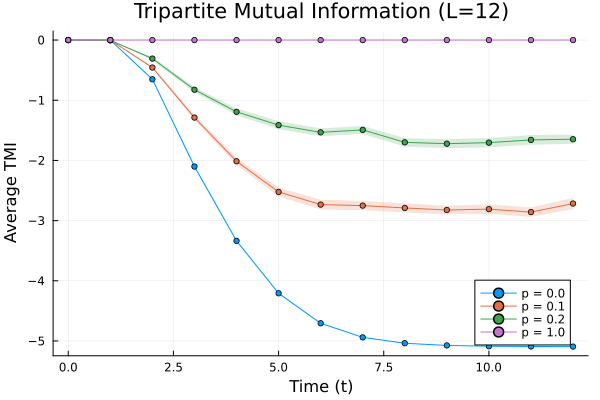

Plot saved as TMI_averaged_L12.svg


In [11]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
L = 12
T = 12.0
dt = 1.0  # Assuming dt=1.0 based on your previous code
num_shots = 500 # You mentioned 500 shots
p_values = [0.0, 0.1, 0.2, 1.0]

# Directory where files are saved (current dir by default)
data_dir = "." 

# ==========================================
# PROCESSING LOOP
# ==========================================

# Initialize Plot
plt = plot(
    title = "Tripartite Mutual Information (L=$L)",
    xlabel = "Time (t)",
    ylabel = "Average TMI",
    legend = :bottomright,
    lw = 2
)

results = Dict()

for p in p_values
    println("Processing p = $p ...")
    
    # Store all trajectories for this p
    # We don't know the exact length of the time series yet, so we'll push vectors
    trajectories = Vector{Vector{Float64}}()

    for s in 1:num_shots
        # Construct filename matching your generation script
        # Pattern: L12,T12.0,dt1.0,p0.1,dirQ,s1_tmi.npy
        filename = "L$(L),T$(T),p$(p),s$(s)_tmi.npy"
        filepath = joinpath(data_dir, filename)

        if isfile(filepath)
            # Load the data
            tmi_data = npzread(filepath)
            push!(trajectories, tmi_data)
        else
            # Optional: warn if a specific shot is missing
            # println("  Warning: Shot $s not found ($filename)")
        end
    end

    if isempty(trajectories)
        println("  No data found for p=$p. Skipping.")
        continue
    end

    # Convert vector of vectors to a Matrix for easy averaging
    # Matrix dimensions: (TimeSteps x NumRealizations)
    # hcat concatenates arrays horizontally, so we transpose to get (Realizations x Time)
    data_matrix = hcat(trajectories...) 
    
    # Calculate Mean and Standard Error (SEM)
    # dims=2 averages across the realizations (columns)
    avg_tmi = mean(data_matrix, dims=2)[:]
    std_tmi = std(data_matrix, dims=2)[:]
    sem_tmi = std_tmi ./ sqrt(length(trajectories)) # Standard Error

    # Save processed data for this p
    results[p] = avg_tmi

    # Add to Plot
    time_axis = 0:dt:T  # Assumes your data includes t=0
    
    # Check if time axis length matches data length
    # If standard logic applies, length should be T/dt + 1
    if length(time_axis) != length(avg_tmi)
        # Adjust time axis if necessary based on data shape
        time_axis = range(0, step=dt, length=length(avg_tmi))
    end

    plot!(plt, time_axis, avg_tmi, 
        ribbon = sem_tmi, # Adds a shaded error region
        label = "p = $p", 
        marker = :circle, 
        markersize = 3,
        fillalpha = 0.2
    )
end

# ==========================================
# OUTPUT
# ==========================================

display(plt)
savefig(plt, "TMI_averaged_L$(L).svg")
println("Plot saved as TMI_averaged_L$(L).svg")

# Optional: Save the averaged data to a new summary file
#npzwrite("TMI_averaged_summary_L$(L).npy", results)

In [ ]:
function main()
    s = ArgParseSettings()
    @add_arg_table! s begin
        "--L"
            arg_type = Int
            required = true
        "--p"
            arg_type = Float64
            required = true
        "--start_shot"
            arg_type = Int
            required = true
        "--end_shot"
            arg_type = Int
            required = true
    end

    parsed = parse_args(s)
    L = parsed["L"]
    p = parsed["p"]
    start_shot = parsed["start_shot"]
    end_shot = parsed["end_shot"]

    # enforce positive integers
    if start_shot < 1 || end_shot < 1
        error("Shot indices must be positive integers")
    end
    if end_shot < start_shot
        error("end_shot (end_shot) must be >= start_shot (start_shot)")
    end

    for T in [10.0*L]
        for shot in start_shot:end_shot
            Entropy_t(L, T, dt, p, shot)
        end
    end
end

main()